In [ ]:
import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib.dates as mdates

# Outlier Treatment

from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer

# Modeling

import xgboost as xgb

# Metrics

from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/processed_data.xlsx')

In [ ]:
X_train = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/X_train_cost_prediction.xlsx')
y_train = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/y_train_cost_prediction.xlsx')
X_test = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/X_test_cost_prediction.xlsx')
y_test = pd.read_excel('/content/drive/MyDrive/Cost Prediction/WORK/y_test_cost_prediction.xlsx')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (196, 10)
X_test shape: (49, 10)
y_train shape: (196, 1)
y_test shape: (49, 1)


# Modeling

In [ ]:
best_params = {
'random_state':42
}

In [ ]:
def test_params(ModelClass, train_inputs, train_target, test_inputs, test_target, **params):
  model = ModelClass(**params).fit(train_inputs, train_target)

  train_rmse = root_mean_squared_error(model.predict(train_inputs), train_target)
  test_rmse = root_mean_squared_error(model.predict(test_inputs), test_target)
  return train_rmse, test_rmse

# testing and plotting

def test_param_and_plot(ModelClass, param_name, param_values, train_inputs, train_target, test_inputs, test_target, **other_params):
  train_errors = []
  test_errors = []

  param_values_list = list(param_values)

  for value in param_values_list:
    params = dict(other_params)
    params[param_name] = value
    train_rmse, test_rmse = test_params(ModelClass, train_inputs, train_target, test_inputs, test_target, **params)
    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

  dataframe_for_plot = pd.DataFrame({
      'param_values': param_values_list,
      'Training': train_errors,
      'Testing': test_errors
  })

  fig = px.line(dataframe_for_plot,
                x='param_values',
                y=['Training', 'Testing'],
                title=f'Overfitting curve ' + param_name,
                labels={'value': 'RMSE', 'param_values': param_name},
                markers=True)

  fig.update_layout(
      xaxis_title=param_name,
      yaxis_title='RMSE',
      legend_title='Metric'
  )
  fig.show()

learning_rate

In [ ]:
test_param_and_plot(
    ModelClass=xgb.XGBRegressor,
    param_name='learning_rate',
    param_values=np.arange(0,1,0.01),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

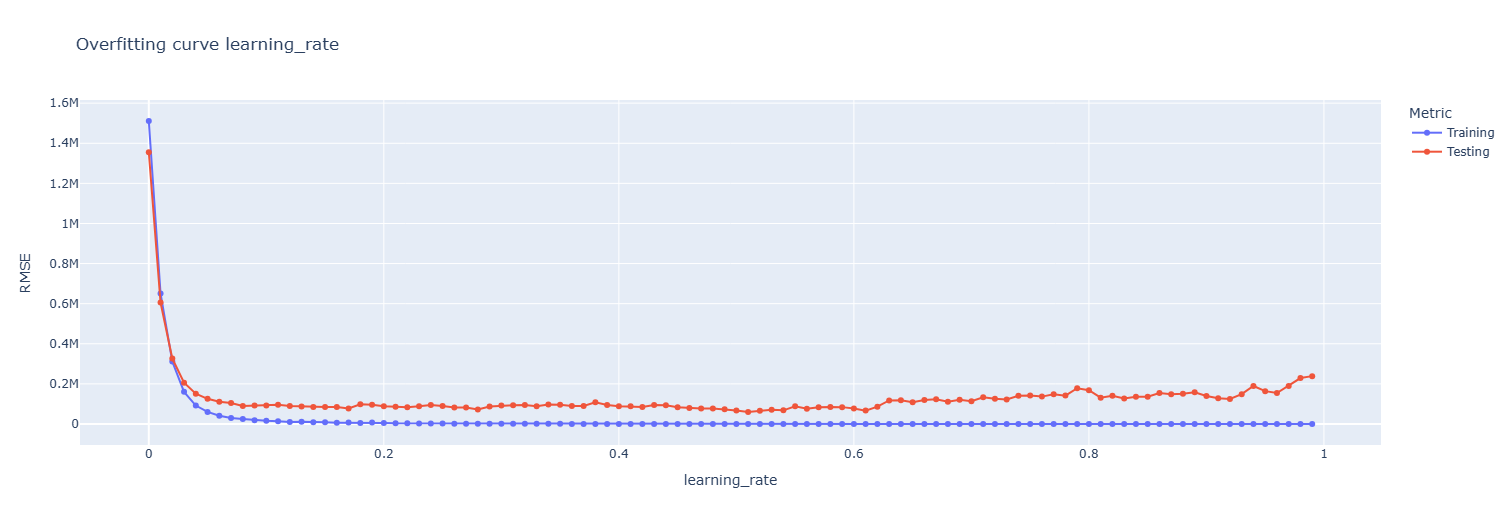

In [ ]:
best_params['learning_rate'] = 0.61

min_split_loss

In [ ]:
test_param_and_plot(
    ModelClass=xgb.XGBRegressor,
    param_name='min_split_loss',
    param_values=range(0,100,2),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

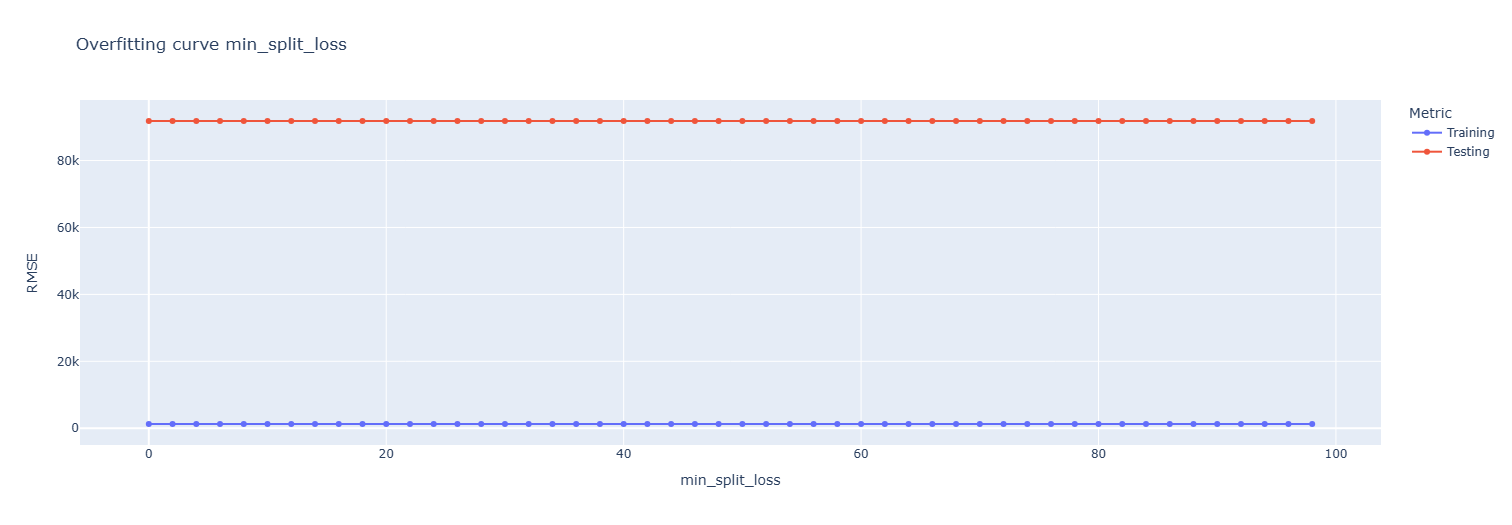

max_depth

In [ ]:
test_param_and_plot(
    ModelClass=xgb.XGBRegressor,
    param_name='max_depth',
    param_values=range(0,100,2),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

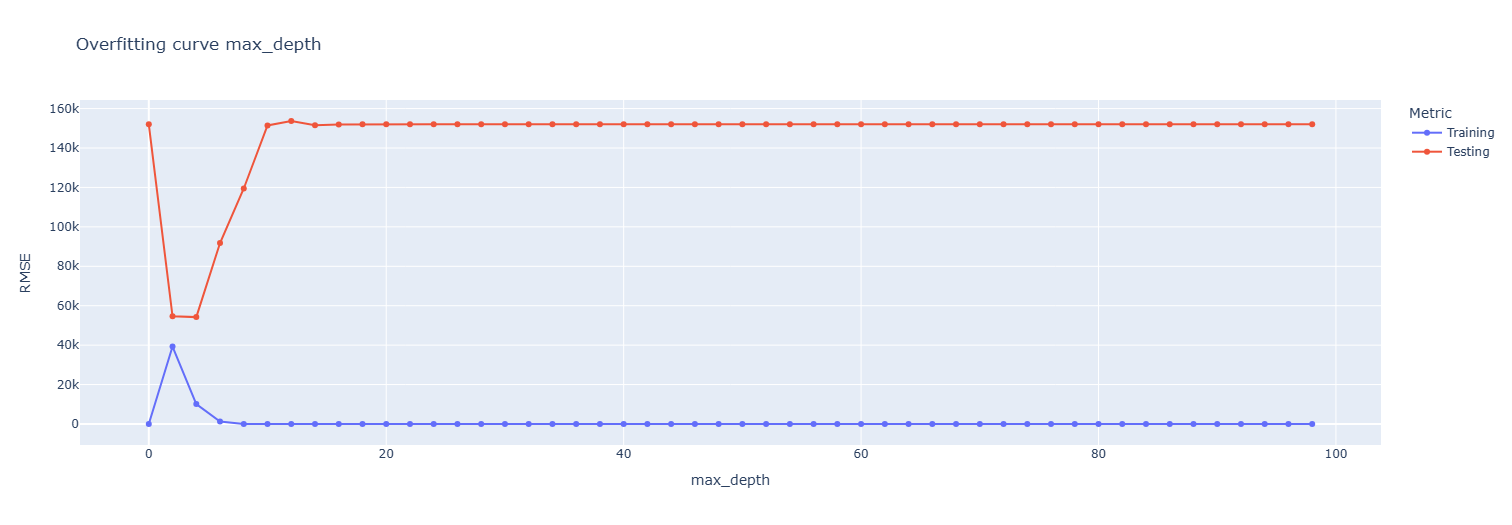

In [ ]:
best_params['max_depth'] = 2

min_child_weight

In [ ]:
test_param_and_plot(
    ModelClass=xgb.XGBRegressor,
    param_name='min_child_weight',
    param_values=range(0,100,2),
    train_inputs=X_train,
    train_target=y_train,
    test_inputs=X_test,
    test_target=y_test,
)

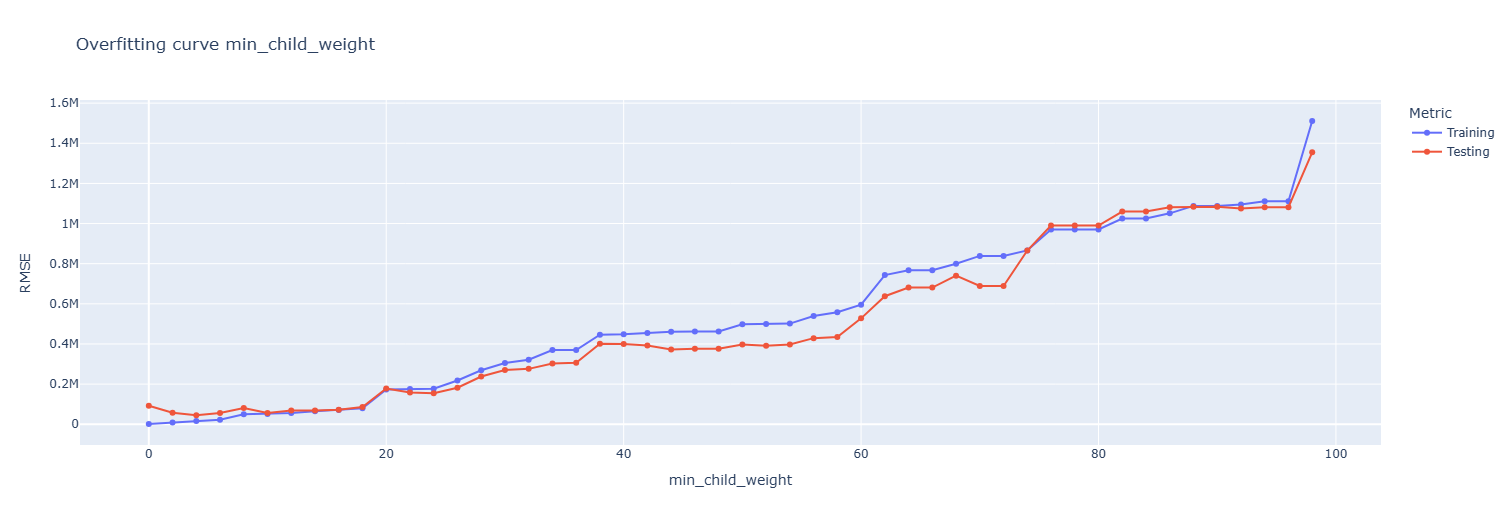

In [ ]:
best_params['min_child_weight'] = 10

In [ ]:
best_params

{'learning_rate': 0.61, 'max_depth': 2, 'min_child_weight': 10}

# Prediction

In [ ]:
model_xgb = xgb.XGBRegressor(**best_params).fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)

In [ ]:
def plot_regression_results(y_true, y_pred, title='Regression Predictions'):
    plt.figure(figsize=(10, 6))

    # Scatter plot of actual vs. predicted values
    plt.scatter(y_true, y_pred, alpha=0.6, label='Actual vs. Predicted')

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction (y=x)')

    plt.title(title)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Calculate and print metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f'RMSE: {rmse:.4f}')
    mape = mean_absolute_percentage_error(y_true, y_pred)
    print(f'MAPE: {mape:.4f}')
    r2 = r2_score(y_true, y_pred)
    print(f'R2: {r2:.4f}')

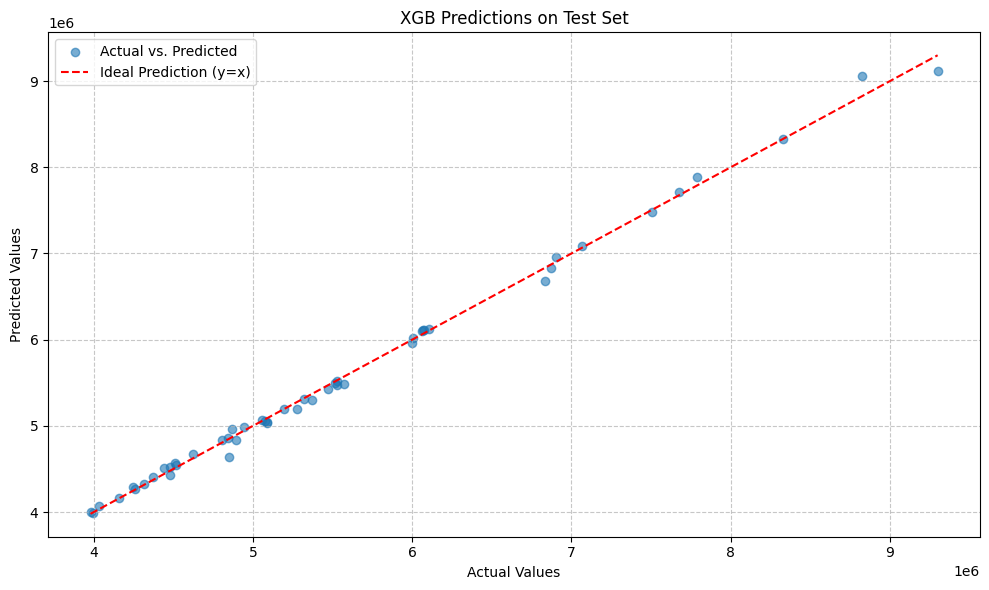

RMSE: 70031.8831
MAPE: 0.0087
R2: 0.9970


In [ ]:
plot_regression_results(y_test.values, xgb_pred, title='XGB Predictions on Test Set')

# Residual Plot

In [ ]:
def residual_plot(y_true, y_pred):

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    residuals = y_true - y_pred

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        x=y_pred,
        y=residuals,
        alpha=0.6
    )

    plt.axhline(y=0, color='r', linestyle='--')

    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title('Residual Plot')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

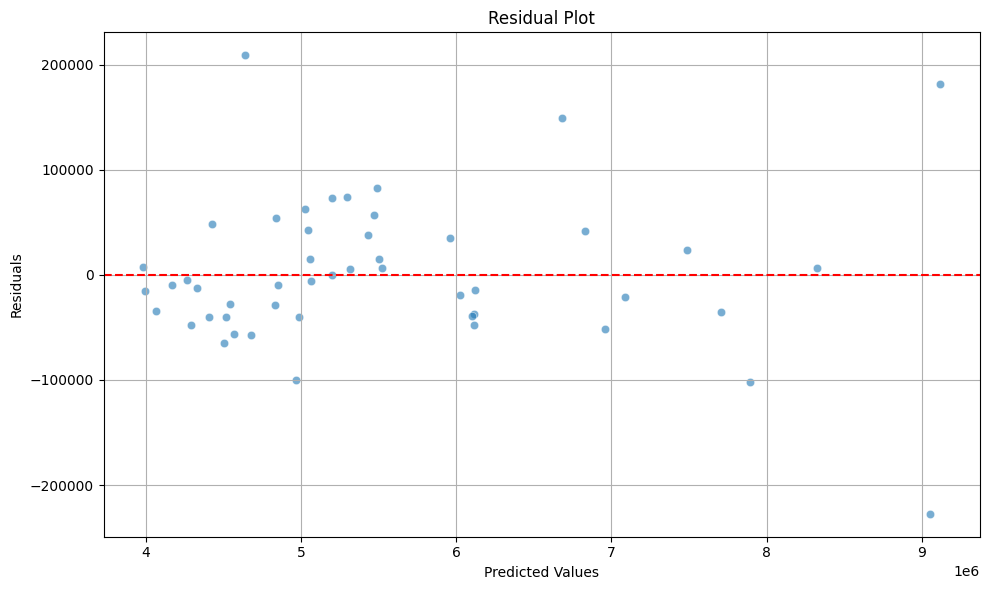

In [ ]:
residual_plot(y_test, xgb_pred)

# Feature Importance

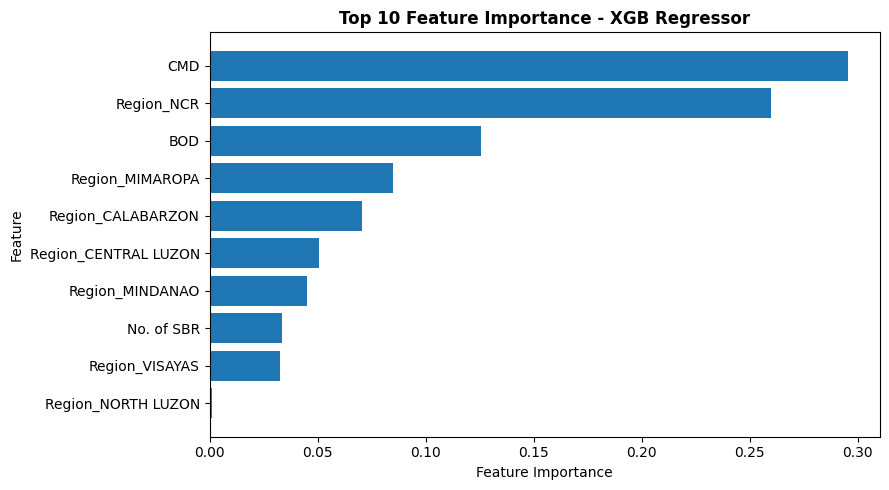

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))

bars = plt.barh(
    feature_importance['Feature'][::-1],
    feature_importance['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance - XGB Regressor',
          fontweight='bold')

plt.tight_layout()
plt.show()

# Bland - Altman Analysis

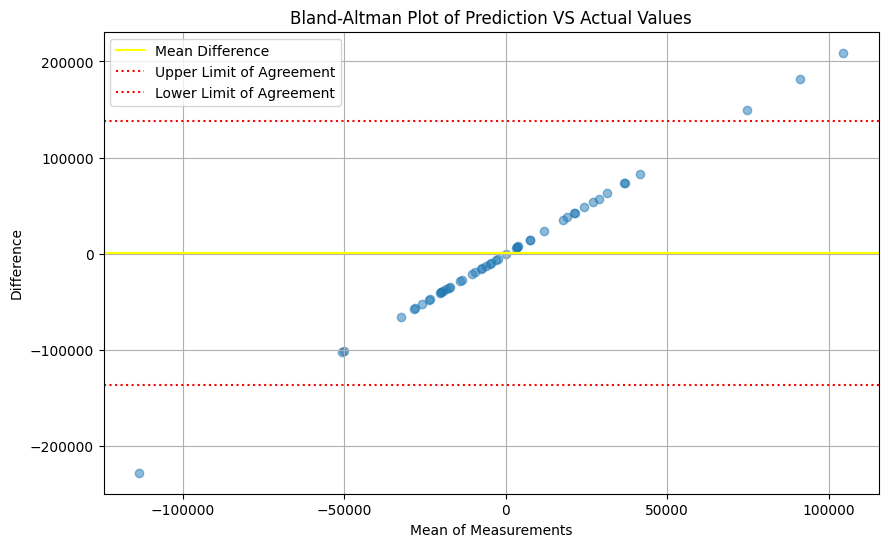

In [ ]:
y_test = np.asarray(y_test).ravel()
y_pred = np.asarray(xgb_pred).ravel()

difference = y_test - y_pred
mean = (y_test - y_pred) / 2

mean_differences = np.mean(difference)
std_differences = np.std(difference)

upper_limit = mean_differences + 1.96 * std_differences
lower_limit = mean_differences - 1.96 * std_differences

plt.figure(figsize=(10, 6))
plt.scatter(mean, difference, alpha=0.5)
plt.axhline(y=mean_differences, color='yellow', linestyle='-', label='Mean Difference')
plt.axhline(y=upper_limit, color='red', linestyle=':', label='Upper Limit of Agreement')
plt.axhline(y=lower_limit, color='red', linestyle=':', label='Lower Limit of Agreement')
plt.xlabel('Mean of Measurements')
plt.ylabel('Difference')
plt.title('Bland-Altman Plot of Prediction VS Actual Values')
plt.legend()
plt.grid(True)
plt.show()


# Hypothesis Testing

- Null Hypothesis (H₀)

There is no statistically significant difference between the actual SBR design costs and the predicted SBR design costs.

- Alternative Hypothesis (H₁)

There is a statistically significant difference between the actual SBR design costs and the predicted SBR design costs.



In [ ]:
ttest=stats.ttest_ind(y_test,xgb_pred)
ttest_df = pd.Series(ttest)

index_ttest = {0: 't-statistic', 1: 'p-value'}
ttest_df = ttest_df.rename(index_ttest)
ttest_df

,0
t-statistic,0.003485
p-value,0.997226


In [ ]:
# Probability that predicted cost is below actual cost
prob_below = np.mean(xgb_pred < y_test) * 100

# Probability that predicted cost is above actual cost
prob_above = np.mean(xgb_pred > y_test) * 100

print(f"Probability of underprediction: {prob_below:.2f}%")
print(f"Probability of overprediction: {prob_above:.2f}%")

Probability of underprediction: 44.90%
Probability of overprediction: 55.10%
